# Imports

In [9]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import warnings
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)

INTERMEDIATE = Path('../data/02_intermediate')
PRIMARY      = Path('../data/03_primary')
PRIMARY.mkdir(parents=True, exist_ok=True)

# Universo de municipios base
df_nbi = pd.read_parquet(INTERMEDIATE / 'nbi_limpia.parquet')
MUNICIPIOS = df_nbi[['divipola','nombre_municipio']].copy()
MUNICIPIOS.columns = ['divipola','municipio']
N = len(MUNICIPIOS)

print(f'✅ Universo base: {N:,} municipios')
print(f'✅ INTERMEDIATE: {INTERMEDIATE}')
print(f'✅ PRIMARY: {PRIMARY}')

✅ Universo base: 1,122 municipios
✅ INTERMEDIATE: ..\data\02_intermediate
✅ PRIMARY: ..\data\03_primary


# Feature 1: Suficiencia productiva EVA

In [10]:
print('='*60)
print('FEATURE 1 — Suficiencia Productiva (EVA)')
print('='*60)

df_eva = pd.read_parquet(INTERMEDIATE / 'eva_limpia.parquet')

# Agregar por municipio — último año disponible (2024)
df_eva_2024 = df_eva[df_eva['anio'] == 2024].copy()

# Indicadores por municipio
eva_mpio = df_eva_2024.groupby('divipola').agg(
    produccion_total_ton  = ('produccion_ton',   'sum'),
    area_sembrada_total_ha= ('area_sembrada_ha', 'sum'),
    n_cultivos            = ('cultivo',          'nunique'),
    rendimiento_promedio  = ('rendimiento_ton_ha','mean'),
).reset_index()

# Diversificación — número de cultivos como proxy
eva_mpio['indice_diversificacion'] = eva_mpio['n_cultivos']

# Municipios sin reporte EVA 2024 → 0
eva_features = MUNICIPIOS.merge(eva_mpio, on='divipola', how='left')
eva_features = eva_features.fillna({
    'produccion_total_ton':   0,
    'area_sembrada_total_ha': 0,
    'n_cultivos':             0,
    'rendimiento_promedio':   0,
    'indice_diversificacion': 0,
})

print(f'\nCobertura: {eva_mpio["divipola"].nunique():,}/{N:,} municipios con EVA 2024')
print(f'Sin reporte: {N - eva_mpio["divipola"].nunique():,} municipios → valor 0')
print(f'\nEstadísticas:')
print(eva_features[['produccion_total_ton','n_cultivos','rendimiento_promedio']].describe().to_string())
print(f'\nTop 5 mayor producción:')
print(eva_features.nlargest(5,'produccion_total_ton')[['divipola','municipio','produccion_total_ton','n_cultivos']].to_string())

pq.write_table(pa.Table.from_pandas(eva_features), PRIMARY / 'feat_eva.parquet', compression='snappy')
print(f'\n💾 Guardado: feat_eva.parquet')

FEATURE 1 — Suficiencia Productiva (EVA)

Cobertura: 1,100/1,122 municipios con EVA 2024
Sin reporte: 22 municipios → valor 0

Estadísticas:
       produccion_total_ton  n_cultivos  rendimiento_promedio
count               1122.00     1122.00               1122.00
mean               58262.72       14.58                  9.94
std               234325.74        7.10                  4.97
min                    0.00        0.00                  0.00
25%                 3502.72       10.00                  6.53
50%                11021.04       13.00                  9.34
75%                34207.79       18.00                 12.62
max              4757616.55       51.00                 55.00

Top 5 mayor producción:
     divipola   municipio  produccion_total_ton  n_cultivos
1031    76520     PALMIRA            4757616.55       33.00
1016    76130  CANDELARIA            3098981.21       16.00
1046    76895      ZARZAL            2097607.97       13.00
1021    76248  EL CERRITO           

NameError: name 'feat_eva' is not defined

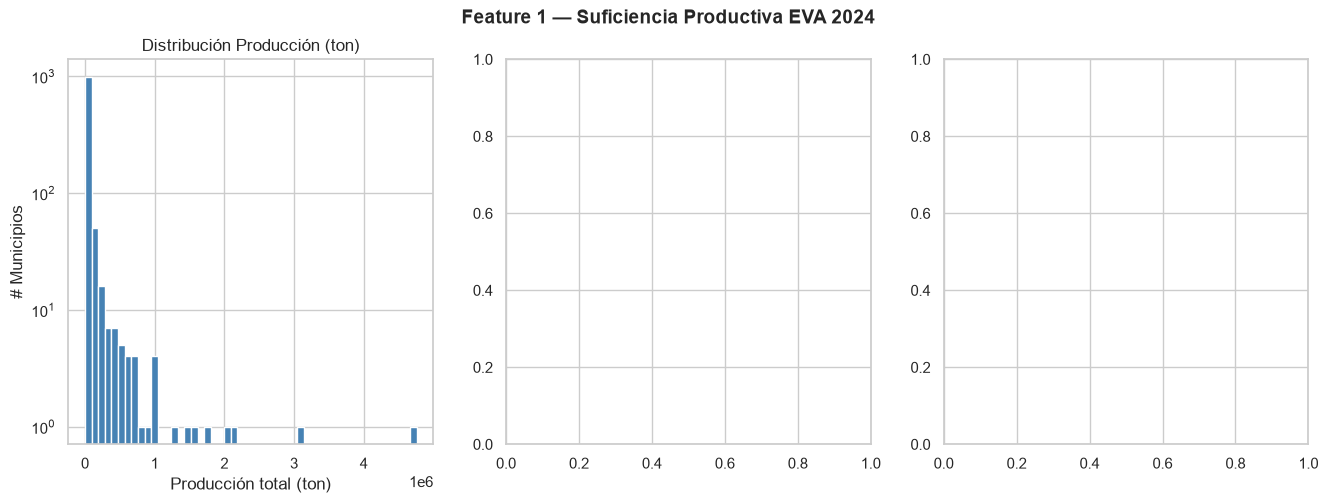

In [ ]:
sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Feature 1 — Suficiencia Productiva EVA 2024', fontsize=14, fontweight='bold')

# Distribución producción
axes[0].hist(
    eva_features[eva_features['produccion_total_ton'] > 0]['produccion_total_ton'],
    bins=50, color='steelblue', edgecolor='white'
)
axes[0].set_title('Distribución Producción (ton)')
axes[0].set_xlabel('Producción total (ton)')
axes[0].set_ylabel('# Municipios')
axes[0].set_yscale('log')

# Distribución número de cultivos
sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Feature 1 — Suficiencia Productiva EVA 2024', fontsize=14, fontweight='bold')

# Distribución producción
axes[0].hist(
    eva_features[eva_features['produccion_total_ton'] > 0]['produccion_total_ton'],
    bins=50, color='steelblue', edgecolor='white'
)
axes[0].set_title('Distribución Producción (ton)')
axes[0].set_xlabel('Producción total (ton)')
axes[0].set_ylabel('# Municipios')
axes[0].set_yscale('log')

# Distribución número de cultivos
axes[1].hist(
    eva_features[eva_features['n_cultivos'] > 0]['n_cultivos'],
    bins=30, color='seagreen', edgecolor='white'
)
axes[1].set_title('Diversificación de Cultivos')
axes[1].set_xlabel('# Cultivos únicos')
axes[1].set_ylabel('# Municipios')

# Top 15 municipios por producción
top15 = eva_features.nlargest(15, 'produccion_total_ton')
axes[2].barh(top15['municipio'], top15['produccion_total_ton']/1e6,
             color='steelblue')
axes[2].set_title('Top 15 Municipios por Producción')
axes[2].set_xlabel('Producción (millones ton)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/figures/feat_eva.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado: reports/figures/feat_eva.png')
axes[1].set_title('Diversificación de Cultivos')
axes[1].set_xlabel('# Cultivos únicos')
axes[1].set_ylabel('# Municipios')

# Top 15 municipios por producción
top15 = feat_eva.nlargest(15, 'produccion_total_ton')
axes[2].barh(top15['municipio'], top15['produccion_total_ton']/1e6,
             color='steelblue')
axes[2].set_title('Top 15 Municipios por Producción')
axes[2].set_xlabel('Producción (millones ton)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/figures/feat_eva.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado: reports/figures/feat_eva.png')



# Feature 2: Aptitud de suelos

In [ ]:
print('='*60)
print('FEATURE 2 — Aptitud de Suelos UPRA')
print('='*60)

df_apt = pd.read_parquet(INTERMEDIATE / 'aptitud_nacional_limpia.parquet')

# Por municipio y cultivo: % área por categoría de aptitud
apt_pivot = df_apt.groupby(['divipola','cultivo','aptitud'])['area_ha'].sum().reset_index()

# Score de aptitud: Alta=3, Media=2, Baja=1, No apta=0, Exclusión=0
scores = {'Aptitud alta': 3, 'Aptitud media': 2, 'Aptitud baja': 1,
          'No apta': 0, 'Exclusión legal': 0}
apt_pivot['score'] = apt_pivot['aptitud'].map(scores)
apt_pivot['score_ponderado'] = apt_pivot['score'] * apt_pivot['area_ha']

# Score promedio por municipio (todos los cultivos)
apt_mpio = apt_pivot.groupby('divipola').agg(
    area_total_ha        = ('area_ha',         'sum'),
    score_aptitud_total  = ('score_ponderado', 'sum'),
).reset_index()
apt_mpio['score_aptitud_promedio'] = (
    apt_mpio['score_aptitud_total'] / apt_mpio['area_total_ha']
).round(4)

# % área alta aptitud por municipio
area_alta = apt_pivot[apt_pivot['aptitud'] == 'Aptitud alta'].groupby('divipola')['area_ha'].sum()
apt_mpio = apt_mpio.merge(area_alta.rename('area_alta_ha'), on='divipola', how='left')
apt_mpio['pct_area_alta_aptitud'] = (
    apt_mpio['area_alta_ha'] / apt_mpio['area_total_ha'] * 100
).round(2)

apt_features = MUNICIPIOS.merge(apt_mpio, on='divipola', how='left')
apt_features = apt_features.fillna({
    'score_aptitud_promedio': 0,
    'pct_area_alta_aptitud':  0,
})

print(f'\nCobertura: {apt_mpio["divipola"].nunique():,}/{N:,} municipios')
print(f'\nEstadísticas score aptitud:')
print(apt_features[['score_aptitud_promedio','pct_area_alta_aptitud']].describe().to_string())
print(f'\nTop 5 mayor aptitud:')
print(apt_features.nlargest(5,'score_aptitud_promedio')[['divipola','municipio','score_aptitud_promedio','pct_area_alta_aptitud']].to_string())
print(f'\nTop 5 menor aptitud:')
print(apt_features.nsmallest(5,'score_aptitud_promedio')[['divipola','municipio','score_aptitud_promedio','pct_area_alta_aptitud']].to_string())

pq.write_table(pa.Table.from_pandas(apt_features), PRIMARY / 'feat_aptitud.parquet', compression='snappy')
print(f'\n💾 Guardado: feat_aptitud.parquet')

FEATURE 2 — Aptitud de Suelos UPRA

Cobertura: 1,122/1,122 municipios

Estadísticas score aptitud:
       score_aptitud_promedio  pct_area_alta_aptitud
count                 1122.00                1122.00
mean                     0.18                   2.67
std                      0.28                   6.55
min                      0.00                   0.00
25%                      0.04                   0.38
50%                      0.08                   1.19
75%                      0.16                   2.43
max                      2.31                  74.30

Top 5 mayor aptitud:
    divipola             municipio  score_aptitud_promedio  pct_area_alta_aptitud
710    50680  SAN CARLOS DE GUAROA                    2.31                  74.30
697    50313               GRANADA                    2.27                  73.14
690    50150     CASTILLA LA NUEVA                    2.25                  73.89
696    50287         FUENTE DE ORO                    2.03                

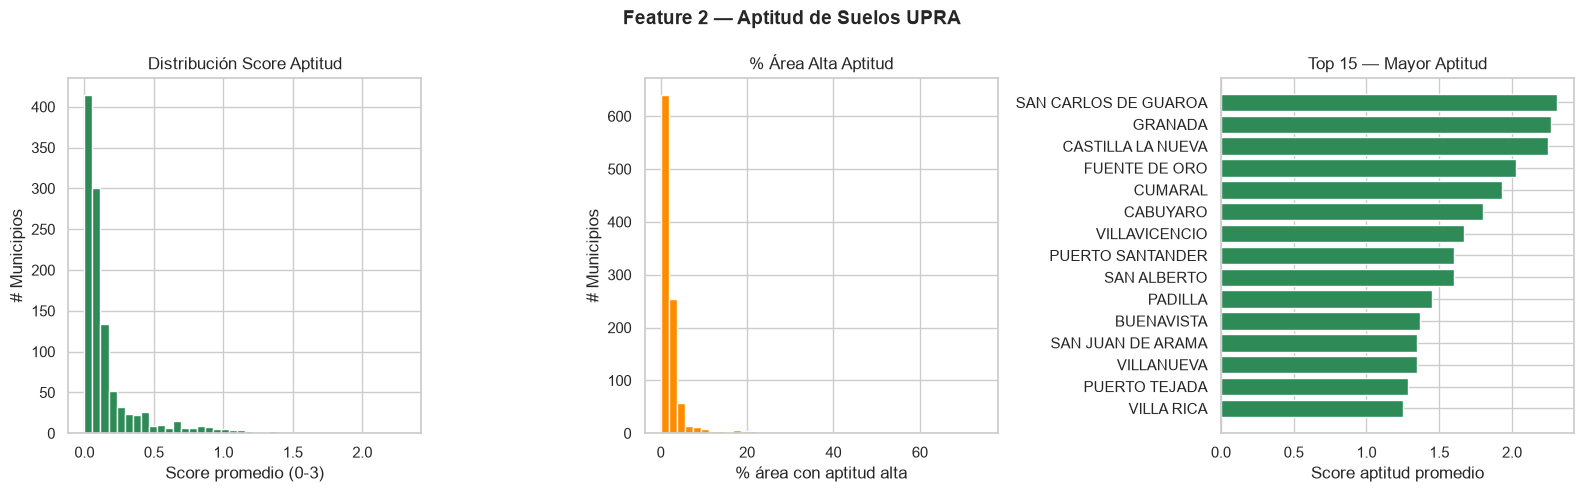

💾 Guardado: reports/figures/feat_aptitud.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Feature 2 — Aptitud de Suelos UPRA', fontsize=14, fontweight='bold')

# Distribución score aptitud
axes[0].hist(feat_apt[feat_apt['score_aptitud_promedio']>0]['score_aptitud_promedio'],
             bins=40, color='seagreen', edgecolor='white')
axes[0].set_title('Distribución Score Aptitud')
axes[0].set_xlabel('Score promedio (0-3)')
axes[0].set_ylabel('# Municipios')

# % área alta aptitud
axes[1].hist(feat_apt[feat_apt['pct_area_alta_aptitud']>0]['pct_area_alta_aptitud'],
             bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('% Área Alta Aptitud')
axes[1].set_xlabel('% área con aptitud alta')
axes[1].set_ylabel('# Municipios')

# Top 15 municipios por score
top15 = feat_apt.nlargest(15, 'score_aptitud_promedio')
axes[2].barh(top15['municipio'], top15['score_aptitud_promedio'],
             color='seagreen')
axes[2].set_title('Top 15 — Mayor Aptitud')
axes[2].set_xlabel('Score aptitud promedio')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/figures/feat_aptitud.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado: reports/figures/feat_aptitud.png')

# Feature 3: Frontera agrícola

In [ ]:
print('='*60)
print('FEATURE 3 — Frontera Agrícola')
print('='*60)

df_front = pd.read_parquet(INTERMEDIATE / 'frontera_agricola_limpia.parquet')

# Área total y por tipo de frontera por municipio
front_mpio = df_front.groupby(['divipola','tipo_frontera'])['area_ha'].sum().reset_index()
front_pivot = front_mpio.pivot_table(
    index='divipola', columns='tipo_frontera', values='area_ha', fill_value=0
).reset_index()
front_pivot.columns.name = None

# Renombrar columnas
col_map = {}
for col in front_pivot.columns:
    if col == 'divipola':
        continue
    col_map[col] = 'area_' + col.lower().replace(' ', '_') + '_ha'
front_pivot = front_pivot.rename(columns=col_map)

# Área total
front_pivot['area_frontera_total_ha'] = front_pivot.drop(columns=['divipola']).sum(axis=1)

# % área No condicionada (apta para producción sin restricciones)
if 'area_no_condicionada_ha' in front_pivot.columns:
    front_pivot['pct_area_no_condicionada'] = (
        front_pivot['area_no_condicionada_ha'] / front_pivot['area_frontera_total_ha'] * 100
    ).round(2)
else:
    front_pivot['pct_area_no_condicionada'] = 0

front_features = MUNICIPIOS.merge(front_pivot, on='divipola', how='left')
front_features = front_features.fillna(0)

print(f'\nCobertura: {front_pivot["divipola"].nunique():,}/{N:,} municipios')
print(f'Columnas generadas: {[c for c in front_pivot.columns if c != "divipola"]}')
print(f'\nEstadísticas:')
print(front_features[['area_frontera_total_ha','pct_area_no_condicionada']].describe().to_string())

pq.write_table(pa.Table.from_pandas(front_features), PRIMARY / 'feat_frontera.parquet', compression='snappy')
print(f'\n💾 Guardado: feat_frontera.parquet')

FEATURE 3 — Frontera Agrícola

Cobertura: 1,122/1,122 municipios
Columnas generadas: ['area_condicionada_ha', 'area_no_condicionada_ha', 'area_frontera_total_ha', 'pct_area_no_condicionada']

Estadísticas:
       area_frontera_total_ha  pct_area_no_condicionada
count                 1122.00                   1122.00
mean                 38275.35                     46.66
std                 106135.53                     38.73
min                     83.50                      0.00
25%                   8160.31                      2.06
50%                  15170.60                     46.66
75%                  33601.70                     87.00
max                1901774.63                    100.00

💾 Guardado: feat_frontera.parquet


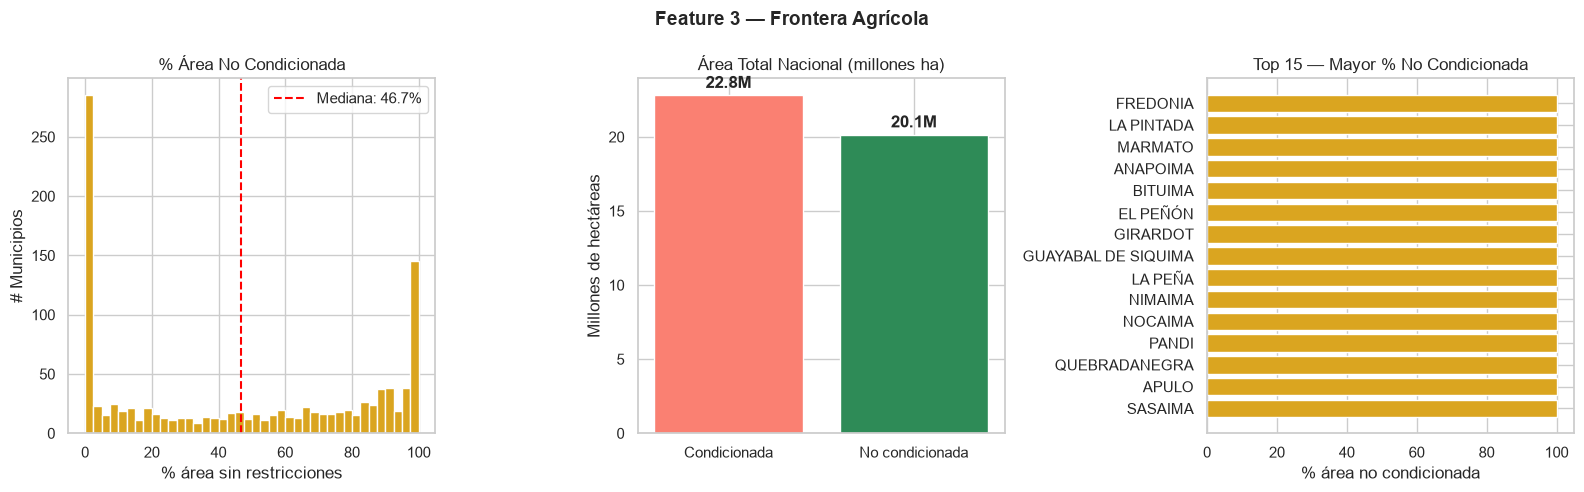

💾 Guardado: reports/figures/feat_frontera.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Feature 3 — Frontera Agrícola', fontsize=14, fontweight='bold')

# Distribución % área no condicionada
axes[0].hist(feat_front['pct_area_no_condicionada'],
             bins=40, color='goldenrod', edgecolor='white')
axes[0].set_title('% Área No Condicionada')
axes[0].set_xlabel('% área sin restricciones')
axes[0].set_ylabel('# Municipios')
axes[0].axvline(feat_front['pct_area_no_condicionada'].median(),
                color='red', linestyle='--', label=f'Mediana: {feat_front["pct_area_no_condicionada"].median():.1f}%')
axes[0].legend()

# Condicionada vs No condicionada — totales nacionales
totales = [
    feat_front['area_condicionada_ha'].sum() / 1e6,
    feat_front['area_no_condicionada_ha'].sum() / 1e6
]
axes[1].bar(['Condicionada', 'No condicionada'], totales,
            color=['salmon','seagreen'], edgecolor='white')
axes[1].set_title('Área Total Nacional (millones ha)')
axes[1].set_ylabel('Millones de hectáreas')
for i, v in enumerate(totales):
    axes[1].text(i, v + 0.5, f'{v:.1f}M', ha='center', fontweight='bold')

# Top 15 mayor % no condicionada
top15 = feat_front.nlargest(15, 'pct_area_no_condicionada')
axes[2].barh(top15['municipio'], top15['pct_area_no_condicionada'],
             color='goldenrod')
axes[2].set_title('Top 15 — Mayor % No Condicionada')
axes[2].set_xlabel('% área no condicionada')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/figures/feat_frontera.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardado: reports/figures/feat_frontera.png')

# Feature 4: Infraestructura de riego

In [ ]:
print('='*60)
print('FEATURE 4 — Infraestructura de Riego')
print('='*60)

df_riego = pd.read_parquet(INTERMEDIATE / 'distritos_riego_limpia.parquet')

# Agregar por municipio
riego_mpio = df_riego.groupby('divipola').agg(
    n_distritos_riego  = ('nombre_del_distrito', 'count'),
    area_riego_bruta_ha= ('area_bruta_ha',        'sum'),
    n_familias_riego   = ('numero_familias',       'sum'),
).reset_index()

riego_features = MUNICIPIOS.merge(riego_mpio, on='divipola', how='left')
riego_features = riego_features.fillna({
    'n_distritos_riego':   0,
    'area_riego_bruta_ha': 0,
    'n_familias_riego':    0,
})

# Binaria: tiene riego o no
riego_features['tiene_riego'] = (riego_features['n_distritos_riego'] > 0).astype(int)

con_riego = riego_features['tiene_riego'].sum()
print(f'\nCobertura: {con_riego:,}/{N:,} municipios con riego activo ({con_riego/N*100:.1f}%)')
print(f'Sin riego: {N-con_riego:,} municipios → valor 0')
print(f'\nEstadísticas área riego:')
print(riego_features[riego_features['tiene_riego']==1]['area_riego_bruta_ha'].describe().to_string())

pq.write_table(pa.Table.from_pandas(riego_features), PRIMARY / 'feat_riego.parquet', compression='snappy')
print(f'\n💾 Guardado: feat_riego.parquet')

FEATURE 4 — Infraestructura de Riego

Cobertura: 278/1,122 municipios con riego activo (24.8%)
Sin riego: 844 municipios → valor 0

Estadísticas área riego:
count     278.00
mean     1202.60
std      4309.47
min         0.00
25%        74.00
50%       177.00
75%       400.00
max     48000.00

💾 Guardado: feat_riego.parquet


# Feature 5: Crédito agropecuario Finagro

In [ ]:
print('='*60)
print('FEATURE 5 — Crédito Agropecuario (Finagro)')
print('='*60)

df_fin = pd.read_parquet(INTERMEDIATE / 'finagro_limpia.parquet')

# Último año disponible
anio_max = df_fin['anio'].max()
df_fin_ultimo = df_fin[df_fin['anio'] == anio_max].copy()
print(f'Usando año: {anio_max}')

# Agregar por municipio
fin_mpio = df_fin_ultimo.groupby('divipola').agg(
    credito_total_cop       = ('colocacion', 'sum'),
    n_creditos              = ('colocacion', 'count'),
    credito_promedio_cop    = ('colocacion', 'mean'),
).reset_index()

# % crédito pequeño productor
pequeno = df_fin_ultimo[df_fin_ultimo['tipo_productor'].str.contains('PEQUE', na=False)]
pequeno_mpio = pequeno.groupby('divipola')['colocacion'].sum().reset_index()
pequeno_mpio.columns = ['divipola','credito_pequeno_cop']

fin_mpio = fin_mpio.merge(pequeno_mpio, on='divipola', how='left')
fin_mpio['credito_pequeno_cop'] = fin_mpio['credito_pequeno_cop'].fillna(0)
fin_mpio['pct_credito_pequeno'] = (
    fin_mpio['credito_pequeno_cop'] / fin_mpio['credito_total_cop'] * 100
).round(2)

fin_features = MUNICIPIOS.merge(fin_mpio, on='divipola', how='left')
fin_features = fin_features.fillna({
    'credito_total_cop':    0,
    'n_creditos':           0,
    'credito_promedio_cop': 0,
    'credito_pequeno_cop':  0,
    'pct_credito_pequeno':  0,
})

print(f'\nCobertura: {fin_mpio["divipola"].nunique():,}/{N:,} municipios')
print(f'\nEstadísticas:')
print(fin_features[['credito_total_cop','n_creditos','pct_credito_pequeno']].describe().to_string())
print(f'\nTop 5 mayor crédito:')
print(fin_features.nlargest(5,'credito_total_cop')[['divipola','municipio','credito_total_cop','pct_credito_pequeno']].to_string())

pq.write_table(pa.Table.from_pandas(fin_features), PRIMARY / 'feat_finagro.parquet', compression='snappy')
print(f'\n💾 Guardado: feat_finagro.parquet')

FEATURE 5 — Crédito Agropecuario (Finagro)
Usando año: 2024

Cobertura: 1,105/1,122 municipios

Estadísticas:
       credito_total_cop  n_creditos  pct_credito_pequeno
count            1122.00     1122.00              1122.00
mean      21634507137.54      351.54                57.66
std      111837147753.33      356.85                32.30
min                 0.00        0.00                 0.00
25%        2887128331.50      138.00                28.86
50%        5986246678.00      263.00                63.77
75%       13402526153.50      455.75                87.43
max     2940812980811.00     5359.00               100.00

Top 5 mayor crédito:
     divipola     municipio  credito_total_cop  pct_credito_pequeno
148     11001  BOGOTÁ, D.C.   2940812980811.00                 4.18
0       05001      MEDELLÍN   1494014836013.00                 2.04
1005    76001          CALI   1086033722162.70                 2.52
478     25214          COTA    589685698730.00                 3.91
58    

# Feature 6: Acceso logístico SIPSA-A

In [ ]:
print('='*60)
print('FEATURE 6 — Acceso Logístico (SIPSA-A)')
print('='*60)

df_sipsa = pd.read_parquet(INTERMEDIATE / 'sipsa_a_limpia.parquet')

# Agregar flujo por municipio origen y grupo
sipsa_mpio = df_sipsa.groupby('divipola').agg(
    flujo_total_kg      = ('Cant Kg', 'sum'),
    n_grupos_alimentarios= ('Grupo',  'nunique'),
    n_registros_sipsa   = ('Cant Kg', 'count'),
).reset_index()

# Flujo por grupo alimentario
grupos = df_sipsa.groupby(['divipola','Grupo'])['Cant Kg'].sum().unstack(fill_value=0).reset_index()
grupos.columns = ['divipola'] + [f'flujo_{g.lower().replace(" ","_").replace(",","")}_kg'
                                  for g in grupos.columns[1:]]

sipsa_features = MUNICIPIOS.merge(sipsa_mpio, on='divipola', how='left')
sipsa_features = sipsa_features.merge(grupos, on='divipola', how='left')
sipsa_features = sipsa_features.fillna(0)

con_sipsa = sipsa_mpio['divipola'].nunique()
print(f'\nCobertura: {con_sipsa:,}/{N:,} municipios con flujo SIPSA-A ({con_sipsa/N*100:.1f}%)')
print(f'Sin flujo: {N-con_sipsa:,} municipios → valor 0')
print(f'\nGrupos alimentarios: {df_sipsa["Grupo"].unique().tolist()}')
print(f'\nEstadísticas flujo total:')
print(sipsa_features['flujo_total_kg'].describe().to_string())

pq.write_table(pa.Table.from_pandas(sipsa_features), PRIMARY / 'feat_sipsa_a.parquet', compression='snappy')
print(f'\n💾 Guardado: feat_sipsa_a.parquet')

FEATURE 6 — Acceso Logístico (SIPSA-A)

Cobertura: 958/1,122 municipios con flujo SIPSA-A (85.4%)
Sin flujo: 164 municipios → valor 0

Grupos alimentarios: ['CARNES', 'TUBERCULOS, RAICES Y PLATANOS', 'FRUTAS', 'VERDURAS Y HORTALIZAS', 'GRANOS Y CEREALES', 'PROCESADOS', 'LACTEOS Y HUEVOS', 'PESCADOS']

Estadísticas flujo total:
count       1122.00
mean     2127153.31
std      6136065.21
min            0.00
25%        10000.00
50%       202222.00
75%      1254161.50
max     88648945.00

💾 Guardado: feat_sipsa_a.parquet


# Feature 7: Vulnerabilidad climática

In [ ]:
print('='*60)
print('FEATURE 7 — Vulnerabilidad Climática (IDEAM + ONI)')
print('='*60)

df_norm = pd.read_parquet(INTERMEDIATE / 'normales_con_divipola.parquet')
df_oni  = pd.read_parquet(INTERMEDIATE / 'oni_limpia.parquet')

# Precipitación normal anual por municipio (promedio de estaciones)
precip = df_norm[df_norm['parametro'] == 'PRECIPITACIÓN'].copy()
precip_mpio = precip.groupby('divipola').agg(
    precipitacion_anual_mm  = ('anual', 'mean'),
    n_estaciones_precip     = ('anual', 'count'),
).reset_index()

# Temperatura media por municipio
temp = df_norm[df_norm['parametro'] == 'TEMPERATURA MEDIA'].copy()
temp_mpio = temp.groupby('divipola').agg(
    temperatura_media_c = ('anual', 'mean'),
).reset_index()

# ONI más reciente
oni_reciente = df_oni.tail(3)['anom'].mean()
fase_actual  = df_oni.tail(1)['fase_enos'].values[0]
print(f'ONI reciente (últimas 3 temporadas): {oni_reciente:.2f} — Fase: {fase_actual}')

# Combinar
clima_features = MUNICIPIOS.copy()
clima_features = clima_features.merge(precip_mpio, on='divipola', how='left')
clima_features = clima_features.merge(temp_mpio,   on='divipola', how='left')
clima_features['oni_anomalia_reciente'] = oni_reciente
clima_features['fase_enos_actual']      = fase_actual

# Imputación por mediana nacional para municipios sin estación
mediana_precip = clima_features['precipitacion_anual_mm'].median()
mediana_temp   = clima_features['temperatura_media_c'].median()
clima_features['precipitacion_anual_mm'] = clima_features['precipitacion_anual_mm'].fillna(mediana_precip)
clima_features['temperatura_media_c']    = clima_features['temperatura_media_c'].fillna(mediana_temp)
clima_features['n_estaciones_precip']    = clima_features['n_estaciones_precip'].fillna(0)

con_clima = precip_mpio['divipola'].nunique()
print(f'\nCobertura directa: {con_clima:,}/{N:,} municipios con estación propia')
print(f'Imputados por mediana: {N-con_clima:,} municipios')
print(f'\nPrecipitación normal — promedio: {clima_features["precipitacion_anual_mm"].mean():.0f} mm/año')
print(f'Temperatura media    — promedio: {clima_features["temperatura_media_c"].mean():.1f} °C')

pq.write_table(pa.Table.from_pandas(clima_features), PRIMARY / 'feat_clima.parquet', compression='snappy')
print(f'\n💾 Guardado: feat_clima.parquet')

FEATURE 7 — Vulnerabilidad Climática (IDEAM + ONI)
ONI reciente (últimas 3 temporadas): 0.54 — Fase: El Niño

Cobertura directa: 779/1,122 municipios con estación propia
Imputados por mediana: 343 municipios

Precipitación normal — promedio: 1999 mm/año
Temperatura media    — promedio: 23.2 °C

💾 Guardado: feat_clima.parquet


# Feature 8: Socioeconómico

In [ ]:
print('='*60)
print('FEATURE 8 — Condición Socioeconómica (NBI + IPM)')
print('='*60)

df_nbi  = pd.read_parquet(INTERMEDIATE / 'nbi_limpia.parquet')
df_ipm  = pd.read_parquet(INTERMEDIATE / 'ipm_limpia.parquet')
df_priv = pd.read_parquet(INTERMEDIATE / 'ipm_privaciones_limpia.parquet')
df_inf  = pd.read_parquet(INTERMEDIATE / 'informalidad_limpia.parquet')

# NBI
nbi_sel = df_nbi[['divipola','nbi_total','nbi_rural','miseria_rural']].copy()

# IPM
ipm_sel = df_ipm[['divipola','ipm_total','ipm_rural']].copy()

# Privaciones relevantes para seguridad alimentaria
priv_sel = df_priv[[
    'divipola',
    'Sin acceso a fuente de agua mejorada',
    'Trabajo informal',
    'Tasa de dependencia',
    'Inadecuada eliminación de excretas',
]].copy()
priv_sel.columns = [
    'divipola',
    'priv_sin_agua',
    'priv_trabajo_informal',
    'priv_dependencia',
    'priv_excretas',
]

# Informalidad — expandir de departamento a municipio
df_nbi_inf = df_nbi[['divipola','cod_depto']].copy()
df_nbi_inf['cod_depto'] = df_nbi_inf['divipola'].str[:2]
df_inf_mpio = df_nbi_inf.merge(
    df_inf[['cod_depto','indice_informalidad']],
    on='cod_depto', how='left'
)[['divipola','indice_informalidad']]

# Combinar todo
socio_features = MUNICIPIOS.copy()
socio_features = socio_features.merge(nbi_sel,       on='divipola', how='left')
socio_features = socio_features.merge(ipm_sel,       on='divipola', how='left')
socio_features = socio_features.merge(priv_sel,      on='divipola', how='left')
socio_features = socio_features.merge(df_inf_mpio,   on='divipola', how='left')
socio_features = socio_features.fillna(0)

print(f'\nCobertura: {len(socio_features[socio_features["nbi_total"]>0]):,}/{N:,} municipios con NBI')
print(f'\nEstadísticas socioeconómicas:')
print(socio_features[['nbi_rural','ipm_rural','priv_sin_agua','priv_trabajo_informal']].describe().to_string())

pq.write_table(pa.Table.from_pandas(socio_features), PRIMARY / 'feat_socioeconomico.parquet', compression='snappy')
print(f'\n💾 Guardado: feat_socioeconomico.parquet')

FEATURE 8 — Condición Socioeconómica (NBI + IPM)

Cobertura: 1,122/1,122 municipios con NBI

Estadísticas socioeconómicas:
       nbi_rural  ipm_rural  priv_sin_agua  priv_trabajo_informal
count    1122.00    1122.00        1122.00                1122.00
mean       27.19      51.06          27.11                  87.58
std        19.05      17.54          21.93                   6.83
min         2.97       8.10           0.20                  58.70
25%        13.45      39.15           9.80                  84.20
50%        20.57      50.80          21.40                  89.25
75%        35.03      63.10          38.70                  92.60
max        95.96      99.20          99.00                 100.00

💾 Guardado: feat_socioeconomico.parquet


# Tabla maestra municipio_features

In [ ]:
print('='*60)
print('INTEGRACIÓN — Tabla Maestra municipio_features')
print('='*60)

# Cargar todos los features
feat_eva    = pd.read_parquet(PRIMARY / 'feat_eva.parquet')
feat_apt    = pd.read_parquet(PRIMARY / 'feat_aptitud.parquet')
feat_front  = pd.read_parquet(PRIMARY / 'feat_frontera.parquet')
feat_riego  = pd.read_parquet(PRIMARY / 'feat_riego.parquet')
feat_fin    = pd.read_parquet(PRIMARY / 'feat_finagro.parquet')
feat_sipsa  = pd.read_parquet(PRIMARY / 'feat_sipsa_a.parquet')
feat_clima  = pd.read_parquet(PRIMARY / 'feat_clima.parquet')
feat_socio  = pd.read_parquet(PRIMARY / 'feat_socioeconomico.parquet')

# Construir tabla maestra
df_master = MUNICIPIOS.copy()

for feat, sufijo in [
    (feat_eva,   'eva'),
    (feat_apt,   'apt'),
    (feat_front, 'front'),
    (feat_riego, 'riego'),
    (feat_fin,   'fin'),
    (feat_sipsa, 'sipsa'),
    (feat_clima, 'clima'),
    (feat_socio, 'socio'),
]:
    cols = [c for c in feat.columns if c not in ['divipola','municipio']]
    df_master = df_master.merge(feat[['divipola'] + cols], on='divipola', how='left')

print(f'\nTabla maestra:')
print(f'  Filas: {len(df_master):,} municipios')
print(f'  Columnas: {len(df_master.columns):,} features')
print(f'\nColumnas por dimensión:')
print(f'  EVA (producción):     {len([c for c in df_master.columns if c in feat_eva.columns and c not in ["divipola","municipio"]]):,}')
print(f'  Aptitud suelos:       {len([c for c in df_master.columns if c in feat_apt.columns and c not in ["divipola","municipio"]]):,}')
print(f'  Frontera agrícola:    {len([c for c in df_master.columns if c in feat_front.columns and c not in ["divipola","municipio"]]):,}')
print(f'  Riego:                {len([c for c in df_master.columns if c in feat_riego.columns and c not in ["divipola","municipio"]]):,}')
print(f'  Finagro (crédito):    {len([c for c in df_master.columns if c in feat_fin.columns and c not in ["divipola","municipio"]]):,}')
print(f'  SIPSA-A (logística):  {len([c for c in df_master.columns if c in feat_sipsa.columns and c not in ["divipola","municipio"]]):,}')
print(f'  Clima:                {len([c for c in df_master.columns if c in feat_clima.columns and c not in ["divipola","municipio"]]):,}')
print(f'  Socioeconómico:       {len([c for c in df_master.columns if c in feat_socio.columns and c not in ["divipola","municipio"]]):,}')

pq.write_table(pa.Table.from_pandas(df_master), PRIMARY / 'municipio_features.parquet', compression='snappy')
print(f'\n💾 Guardado: municipio_features.parquet')
print(f'   Tamaño: {(PRIMARY / "municipio_features.parquet").stat().st_size / 1024:.1f} KB')

INTEGRACIÓN — Tabla Maestra municipio_features

Tabla maestra:
  Filas: 1,122 municipios
  Columnas: 51 features

Columnas por dimensión:
  EVA (producción):     5
  Aptitud suelos:       5
  Frontera agrícola:    4
  Riego:                4
  Finagro (crédito):    5
  SIPSA-A (logística):  11
  Clima:                5
  Socioeconómico:       10

💾 Guardado: municipio_features.parquet
   Tamaño: 283.4 KB


# Análisis de gaps

In [ ]:
print('='*60)
print('ANÁLISIS DE GAPS — Cobertura por dimensión')
print('='*60)

df_master = pd.read_parquet(PRIMARY / 'municipio_features.parquet')

dimensiones = {
    'D1 Producción EVA':       'produccion_total_ton',
    'D1 Aptitud suelos':       'score_aptitud_promedio',
    'D1 Frontera agrícola':    'area_frontera_total_ha',
    'D2 Riego':                'area_riego_bruta_ha',
    'D2 Crédito Finagro':      'credito_total_cop',
    'D2 Flujo SIPSA-A':        'flujo_total_kg',
    'D3 Precipitación':        'precipitacion_anual_mm',
    'D3 Temperatura':          'temperatura_media_c',
    'D4 NBI rural':            'nbi_rural',
    'D4 IPM rural':            'ipm_rural',
    'D4 Informalidad tierras': 'indice_informalidad',
}

print(f'\n{"Dimensión":<30} {"Con datos":>10} {"Sin datos":>10} {"Cobertura":>10}')
print('-'*62)
for dim, col in dimensiones.items():
    if col not in df_master.columns:
        print(f'{dim:<30} {"N/A":>10}')
        continue
    con_datos = (df_master[col] > 0).sum()
    sin_datos = N - con_datos
    cobertura = con_datos / N * 100
    print(f'{dim:<30} {con_datos:>10,} {sin_datos:>10,} {cobertura:>9.1f}%')

# Municipios con todas las dimensiones
cols_check = [v for v in dimensiones.values() if v in df_master.columns]
df_master['todas_dimensiones'] = (df_master[cols_check] > 0).all(axis=1)
completos = df_master['todas_dimensiones'].sum()
print(f'\nMunicipios con TODAS las dimensiones: {completos:,}/{N:,} ({completos/N*100:.1f}%)')
print(f'Municipios con gaps:                  {N-completos:,}/{N:,} ({(N-completos)/N*100:.1f}%)')

# Cuáles tienen más gaps
df_master['n_gaps'] = (df_master[cols_check] == 0).sum(axis=1)
print(f'\nTop 10 municipios con más gaps:')
print(df_master[df_master['n_gaps']>0].nlargest(10,'n_gaps')[['divipola','municipio','n_gaps']].to_string())

ANÁLISIS DE GAPS — Cobertura por dimensión

Dimensión                       Con datos  Sin datos  Cobertura
--------------------------------------------------------------
D1 Producción EVA                   1,099         23      98.0%
D1 Aptitud suelos                   1,113          9      99.2%
D1 Frontera agrícola                1,122          0     100.0%
D2 Riego                              277        845      24.7%
D2 Crédito Finagro                  1,104         18      98.4%
D2 Flujo SIPSA-A                      932        190      83.1%
D3 Precipitación                    1,122          0     100.0%
D3 Temperatura                      1,122          0     100.0%
D4 NBI rural                        1,122          0     100.0%
D4 IPM rural                        1,122          0     100.0%
D4 Informalidad tierras             1,121          1      99.9%

Municipios con TODAS las dimensiones: 256/1,122 (22.8%)
Municipios con gaps:                  866/1,122 (77.2%)

Top 10 muni

# Normalización min-max

In [ ]:
print('='*60)
print('NORMALIZACIÓN Min-Max por dimensión')
print('='*60)

df_master = pd.read_parquet(PRIMARY / 'municipio_features.parquet')

# Columnas a normalizar por dimensión
cols_normalizar = {
    'D1_produccion': [
        'produccion_total_ton','area_sembrada_total_ha',
        'n_cultivos','rendimiento_promedio',
        'score_aptitud_promedio','pct_area_alta_aptitud',
        'pct_area_no_condicionada',
    ],
    'D2_acceso': [
        'area_riego_bruta_ha','n_distritos_riego',
        'credito_total_cop','n_creditos',
        'flujo_total_kg','n_grupos_alimentarios',
    ],
    'D3_clima': [
        'precipitacion_anual_mm','temperatura_media_c',
    ],
    'D4_socioeconomico': [
        'nbi_rural','ipm_rural',
        'priv_sin_agua','priv_trabajo_informal',
        'priv_dependencia','indice_informalidad',
    ],
}

df_norm = df_master.copy()

for dimension, cols in cols_normalizar.items():
    cols_presentes = [c for c in cols if c in df_norm.columns]
    for col in cols_presentes:
        col_min = df_norm[col].min()
        col_max = df_norm[col].max()
        if col_max > col_min:
            df_norm[f'{col}_norm'] = (
                (df_norm[col] - col_min) / (col_max - col_min)
            ).round(4)
        else:
            df_norm[f'{col}_norm'] = 0
    print(f'  {dimension}: {len(cols_presentes)} columnas normalizadas')

# Guardar versión normalizada
pq.write_table(pa.Table.from_pandas(df_norm),
               PRIMARY / 'municipio_features_normalizado.parquet',
               compression='snappy')

print(f'\n✅ Tabla normalizada guardada')
print(f'   Columnas totales: {len(df_norm.columns):,}')
print(f'\nMuestra normalización (Medellín vs Inírida):')
cols_muestra = ['divipola','municipio',
                'produccion_total_ton','produccion_total_ton_norm',
                'nbi_rural','nbi_rural_norm',
                'flujo_total_kg','flujo_total_kg_norm']
cols_muestra = [c for c in cols_muestra if c in df_norm.columns]
medellin = df_norm[df_norm['divipola']=='05001'][cols_muestra]
inirica  = df_norm[df_norm['divipola']=='94001'][cols_muestra]
print(pd.concat([medellin, inirica]).to_string())

NORMALIZACIÓN Min-Max por dimensión
  D1_produccion: 7 columnas normalizadas
  D2_acceso: 6 columnas normalizadas
  D3_clima: 2 columnas normalizadas
  D4_socioeconomico: 6 columnas normalizadas

✅ Tabla normalizada guardada
   Columnas totales: 72

Muestra normalización (Medellín vs Inírida):
     divipola municipio  produccion_total_ton  produccion_total_ton_norm  nbi_rural  nbi_rural_norm  flujo_total_kg  flujo_total_kg_norm
0       05001  MEDELLÍN               9540.77                       0.00       8.57            0.06     35077484.00                 0.40
1099    94001   INÍRIDA               9991.95                       0.00      76.37            0.79         6960.00                 0.00


# Resumen final

In [ ]:
print('='*60)
print('RESUMEN FINAL — data/03_primary')
print('='*60)

archivos = sorted(PRIMARY.glob('*.parquet'))
total_mb = 0

for archivo in archivos:
    mb = archivo.stat().st_size / (1024*1024)
    total_mb += mb
    df_check = pd.read_parquet(archivo)
    print(f'✅ {archivo.name}')
    print(f'   {len(df_check):,} filas × {len(df_check.columns)} columnas | {mb:.1f} MB')

print(f'\nTotal: {len(archivos)} archivos | {total_mb:.1f} MB')
print(f'\n✅ Fase 3 CRISP-DM completada')
print(f'   Feature construction: 8 dimensiones')
print(f'   Tabla maestra: municipio_features.parquet')
print(f'   Tabla normalizada: municipio_features_normalizado.parquet')
print(f'\n➡️  Siguiente: notebook 04_modelo_predictivo.ipynb')
print(f'   AHP — cálculo del IRA compuesto')
print(f'   XGBoost — modelo predictivo de deterioro')

RESUMEN FINAL — data/03_primary
✅ feat_aptitud.parquet
   1,122 filas × 7 columnas | 0.1 MB
✅ feat_clima.parquet
   1,122 filas × 7 columnas | 0.0 MB
✅ feat_eva.parquet
   1,122 filas × 7 columnas | 0.0 MB
✅ feat_finagro.parquet
   1,122 filas × 7 columnas | 0.1 MB
✅ feat_frontera.parquet
   1,122 filas × 6 columnas | 0.1 MB
✅ feat_riego.parquet
   1,122 filas × 6 columnas | 0.0 MB
✅ feat_sipsa_a.parquet
   1,122 filas × 13 columnas | 0.1 MB
✅ feat_socioeconomico.parquet
   1,122 filas × 12 columnas | 0.1 MB
✅ municipio_features.parquet
   1,122 filas × 51 columnas | 0.3 MB
✅ municipio_features_normalizado.parquet
   1,122 filas × 72 columnas | 0.4 MB

Total: 10 archivos | 1.1 MB

✅ Fase 3 CRISP-DM completada
   Feature construction: 8 dimensiones
   Tabla maestra: municipio_features.parquet
   Tabla normalizada: municipio_features_normalizado.parquet

➡️  Siguiente: notebook 04_modelo_predictivo.ipynb
   AHP — cálculo del IRA compuesto
   XGBoost — modelo predictivo de deterioro
